In [15]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import Callback
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import cv2
from tqdm import tqdm

In [2]:
# custom functions
from src.models import resnet_ssd_min
from src.nn_tools import find_overfitting_piont
from src import tf_custom_callbacks

In [3]:
import importlib
def reload_imports():
    importlib.reload(resnet_ssd_min)
    importlib.reload(tf_custom_callbacks)

reload_imports()

In [4]:
# global variables
from config import GLOBAL_CONFIG_RESULT_PATH, GLOBAL_CONFIG_DATA_PATH

In [5]:
# padding image on the right side and top side
def pad_image(img, target_shape):
    img_shape = img.shape
    # Calculate padding for each dimension
    pad_height = target_shape[0] - img_shape[0]
    pad_width = target_shape[1] - img_shape[1]
    # Construct the padding for each axis
    pad_shape = ((0, pad_height), (0, pad_width), (0, 0))  # (top, bottom), (left, right), (channels)
    
    return np.pad(img, pad_shape, mode='constant', constant_values=0)

# resize image to target shape
def resize_image(img, target_shape):
    return cv2.resize(img, target_shape, interpolation=cv2.INTER_NEAREST)

In [6]:
reload_imports()

# define the model
model = resnet_ssd_min.small_resnet_ssd(input_shape=(255, 255, 3), num_classes=2, num_boxes=100)

model.summary()

Model: "small_resnet_ssd"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 255, 255,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ initial_conv        │ (None, 128, 128,  │      2,368 │ input_layer[0][0] │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ initial_bn          │ (None, 128, 128,  │         64 │ initial_conv[0][… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ initial_relu (ReLU) │ (None, 128, 128,  │          0 │ initial_bn[0][0]  │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ initial_pool        │ (None, 64, 64,    │          0 │ initial_relu[0][… │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_block1_conv1   │ (None, 64, 64,    │      2,320 │ initial_pool[0][… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_block1_bn1     │ (None, 64, 64,    │         64 │ conv_block1_conv… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_block1_relu1   │ (None, 64, 64,    │          0 │ conv_block1_bn1[… │
│ (ReLU)              │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_block1_conv2   │ (None, 64, 64,    │      2,320 │ conv_block1_relu… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_block1_bn2     │ (None, 64, 64,    │         64 │ conv_block1_conv… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_block1_add     │ (None, 64, 64,    │          0 │ conv_block1_bn2[… │
│ (Add)               │ 16)               │            │ initial_pool[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_block1_out     │ (None, 64, 64,    │          0 │ conv_block1_add[… │
│ (ReLU)              │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ identity_block1_co… │ (None, 64, 64,    │      2,320 │ conv_block1_out[… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ identity_block1_bn1 │ (None, 64, 64,    │         64 │ identity_block1_… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ identity_block1_re… │ (None, 64, 64,    │          0 │ identity_block1_… │
│ (ReLU)              │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ identity_block1_co… │ (None, 64, 64,    │      2,320 │ identity_block1_… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ identity_block1_bn2 │ (None, 64, 64,    │         64 │ identity_block1_

 Total params: 317,432 (1.21 MB)

 Trainable params: 315,928 (1.21 MB)

 Non-trainable params: 1,504 (5.88 KB)

In [7]:
# load image data
def load_image(image_id, path):
    img = cv2.imread(path + "/" + image_id)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img

In [16]:
# load images, process and ajust bounding boxes and save to disk
save_path = GLOBAL_CONFIG_DATA_PATH + 'processed_images_Segmented/Images/'
csv_save_path = GLOBAL_CONFIG_DATA_PATH + 'processed_images_Segmented/final_annotations.csv'

In [42]:
# load processed images
images = []
df_label = pd.read_csv(csv_save_path)
df_label_unique = df_label[['Image_ID']].drop_duplicates()
num_unique_images = df_label_unique.shape[0]
for i in tqdm(range(0, num_unique_images)):
    # print("image path: ", save_path + df_label_unique.iloc[i]['Image_ID'])
    img = cv2.imread(save_path + df_label_unique.iloc[i]['Image_ID'])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # normalize image
    img = img / 255.0

    images.append(img)

# load processed labels
df_label = pd.read_csv(csv_save_path)

# shape of resized images
# number of images, height, width, channels
print("number of images: ", len(images))
# use float8 for memory efficiency
images = np.array(images, dtype=np.float16)
print("images shape: ", images.shape)

100%|██████████| 29411/29411 [00:55<00:00, 530.34it/s]


number of images:  29411
images shape:  (29411, 255, 255, 3)


In [43]:
# images memory usage
print("images memory usage: ", images.nbytes / 1024 / 1024, "MB")

images memory usage:  10943.128252029419 MB


In [ ]:
# Function to plot an image with its bounding boxes
def plot_image_with_boxes(image, boxes, YOLO_FORMAT=False, show_labels=True):
    # check if the image is float32, if not convert it to float32
    # copy the image to avoid changing the original image
    image = image.copy()
    if image.dtype != np.float32:
        image = image.astype(np.float32)

    # Get image dimensions
    h, w, _ = image.shape

    # Plot the image
    plt.figure(figsize=(10, 10))
    plt.imshow(image)

    # Plot each bounding box
    for box in boxes:
        if YOLO_FORMAT:
            class_id, x_center, y_center, width, height = box
            xmin = int((x_center - width / 2) * w)
            ymin = int((y_center - height / 2) * h)
            xmax = int((x_center + width / 2) * w)
            ymax = int((y_center + height / 2) * h)
        else:
            xmin, ymin, xmax, ymax, class_id = box

        # Draw the bounding box
        plt.gca().add_patch(plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                                          edgecolor='red', facecolor='none', linewidth=2))
        if show_labels:
            plt.text(xmin, ymin - 10, f'Class {int(class_id)}', color='red', fontsize=12, weight='bold')

    plt.axis('off')
    plt.show()

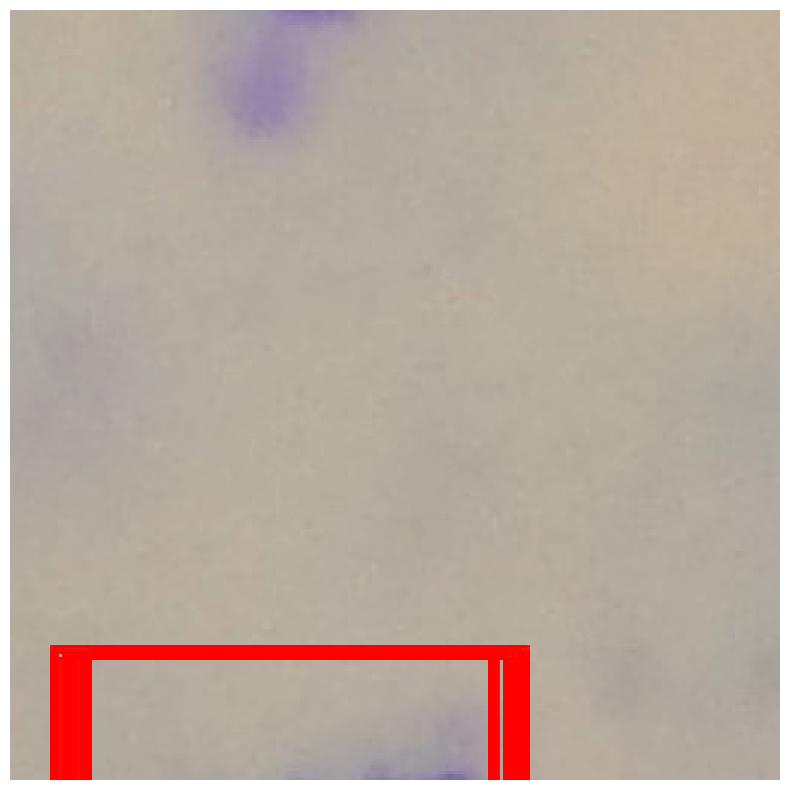

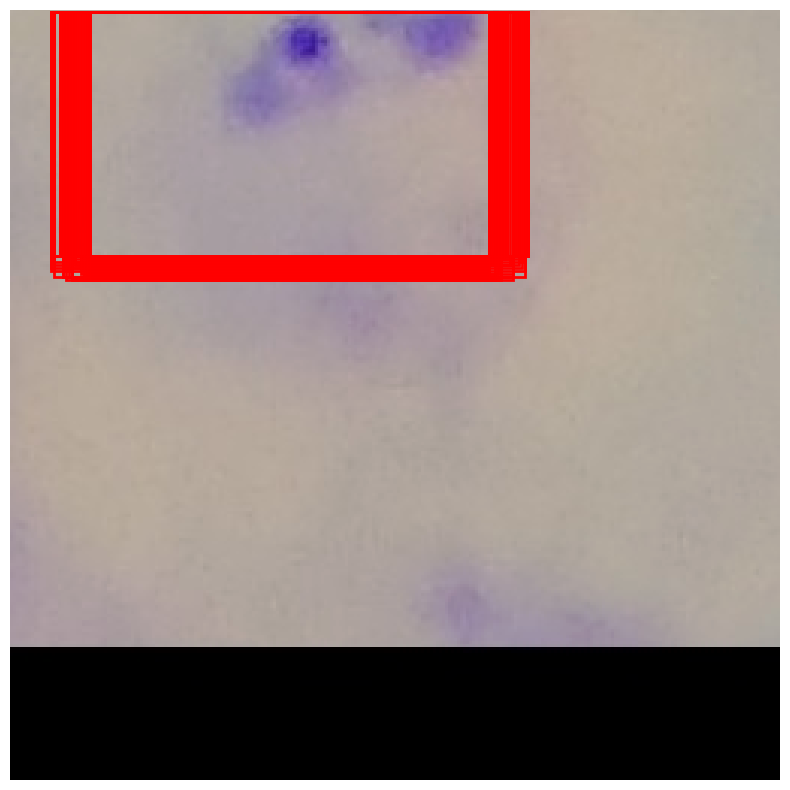

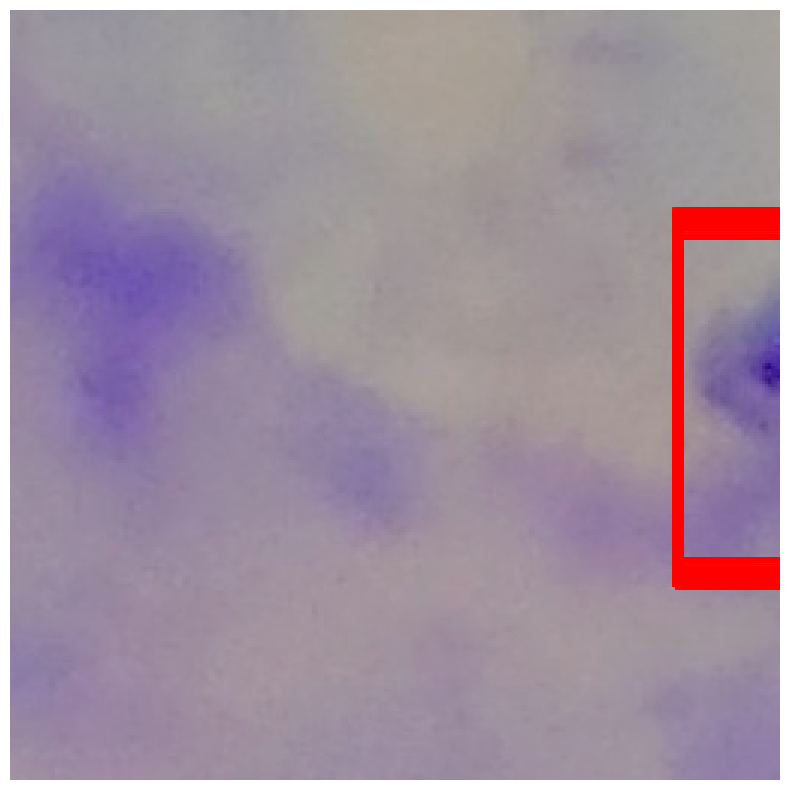

In [23]:
# plot image with bounding boxes to check if they are correct for the first 3 images
for i in range(0, 3):
    u_image_id = df_label_unique.iloc[i]['Image_ID']
    df_label_image = df_label[df_label['Image_ID'] == u_image_id]
    boxes = df_label_image[['xmin', 'ymin', 'xmax', 'ymax', 'class']].values
    plot_image_with_boxes(images[i], boxes, show_labels=False)

In [ ]:
# create dataset
# input: images_resized
# output: (bboxs, (xmin, ymin, xmax, ymax, class1, class2, ...))

target_y = []
target_x = []
removal_list = []
removal_list_index = []

# get max number of bounding boxes from max num instances of an image
max_num_boxes = df_label.groupby('Image_ID').size().max()

num_boxes = model.output_shape[1]
print(f"num_boxes: {num_boxes}")
num_classes = 2

for u_image_id in tqdm(df_label_unique['Image_ID']):
    df_label_image = df_label[df_label['Image_ID'] == u_image_id]

    # get all bounding boxes for this image
    this_target_y = []
    for i in range(0, df_label_image.shape[0]):
        # if class is NEG
        if df_label_image.iloc[i]['class'] == 'NEG':
            continue

        bbox = df_label_image.iloc[i][['xmin', 'ymin', 'xmax', 'ymax']]
        # class_one_hot = pd.get_dummies(df_label_image.iloc[i]['class'])

        def pd_manually_one_hot_encode(class_name, classes):
            one_hot = np.zeros(len(classes))
            one_hot[classes.index(class_name)] = 1
            return one_hot
        
        class_one_hot = pd_manually_one_hot_encode(df_label_image.iloc[i]['class'], ['Trophozoite', 'WBC'])

        # add bounding box and class to target_y
        item = np.concatenate([bbox, class_one_hot])

        this_target_y.append(item)
        
    
    # # load agmented lables to fill the num_boxes
    # agmented_labels_path = GLOBAL_CONFIG_DATA_PATH + 'processed_images_Segmented/augmented_labels.csv'
    # df_agumented_labels = pd.read_csv(agmented_labels_path)

    # if less than num_boxes, add zeros
    if len(this_target_y) < num_boxes:
        # for i in range(len(this_target_y), num_boxes):
        #     item = np.zeros(num_classes + 4)
        #     this_target_y.append(item)

        #     # equally duplicate all items in the list to fill the num_boxes
        #     # this_target_y = duplicate_items(this_target_y, num_boxes)

        new_this_target_y = []

        count = 0
        original_iter = 0

        # print(f"for image: {u_image_id}")

        if len(this_target_y) == 0:
            # add to removal list
            removal_list.append(u_image_id)
            # index of u_image_id
            index = df_label_unique[df_label_unique['Image_ID'] == u_image_id].index[0]
            # if index > df_label_unique.shape[0]:
            #     print(f"shit: {index}")
            removal_list_index.append(len(target_y))

        while count < num_boxes:
            if len(this_target_y) == 0:
                item = np.zeros(num_classes + 4)
                new_this_target_y.append(item)
                count += 1
            for i in range(0, len(this_target_y)):
                # print(f"original_iter: {original_iter}, count: {count}")
                new_this_target_y.append(this_target_y[i])
                count += 1
                original_iter += 1
                if count >= num_boxes:
                    break
        
        this_target_y = new_this_target_y


    target_y.append(this_target_y)

print(f"removal_list: {len(removal_list)}")



In [29]:
import numpy as np
import pandas as pd
from tqdm import tqdm

def process_bounding_boxes(df_label, df_label_unique, num_boxes, classes=['Trophozoite', 'WBC']):
    """
    Efficiently process bounding boxes from DataFrame
    
    Args:
        df_label: DataFrame with bounding box information
        df_label_unique: DataFrame with unique image IDs
        num_boxes: Number of boxes to pad/truncate to
        classes: List of class names for one-hot encoding
    """
    num_classes = len(classes)
    class_to_idx = {cls: idx for idx, cls in enumerate(classes)}
    
    # Pre-allocate arrays for better performance
    target_y = []
    removal_list = []
    removal_list_index = []
    
    # Create a dictionary for faster lookups
    image_groups = dict(tuple(df_label.groupby('Image_ID')))
    
    # Pre-compute the zero padding array
    zero_padding = np.zeros(num_classes + 4)
    
    for idx, u_image_id in enumerate(tqdm(df_label_unique['Image_ID'])):
        df_label_image = image_groups.get(u_image_id)
        
        if df_label_image is None:
            continue
            
        # Filter out NEG class and get relevant rows efficiently
        pos_mask = df_label_image['class'] != 'NEG'
        valid_rows = df_label_image[pos_mask]
        
        # Process all boxes for current image at once
        if len(valid_rows) > 0:
            # Extract bounding boxes
            bboxes = valid_rows[['xmin', 'ymin', 'xmax', 'ymax']].values
            
            # Create one-hot encodings efficiently
            one_hot = np.zeros((len(valid_rows), num_classes))
            for i, cls in enumerate(valid_rows['class']):
                one_hot[i, class_to_idx[cls]] = 1
            
            # Combine bboxes and one-hot encodings
            this_target_y = np.hstack([bboxes, one_hot])
        else:
            this_target_y = np.array([])
            removal_list.append(u_image_id)
            removal_list_index.append(len(target_y))
        
        # Handle padding/truncation efficiently
        if len(this_target_y) == 0:
            # Fill with zeros if no valid boxes
            this_target_y = np.tile(zero_padding, (num_boxes, 1))
        elif len(this_target_y) < num_boxes:
            # Calculate how many times to repeat the existing boxes
            num_repeats = int(np.ceil(num_boxes / len(this_target_y)))
            this_target_y = np.tile(this_target_y, (num_repeats, 1))
            # Truncate to exact number of boxes needed
            this_target_y = this_target_y[:num_boxes]
        else:
            # Truncate if we have too many boxes
            this_target_y = this_target_y[:num_boxes]
        
        target_y.append(this_target_y)
    
    return np.array(target_y), removal_list, removal_list_index

In [30]:
# Process bounding boxes
target_y, removal_list, removal_list_index = process_bounding_boxes(
    df_label,
    df_label_unique,
    num_boxes=model.output_shape[1]
)

# save target_y to disk
import joblib
joblib.dump(target_y, GLOBAL_CONFIG_DATA_PATH + 'processed_images_Segmented/target_y.joblib')

100%|██████████| 29411/29411 [00:07<00:00, 3829.41it/s]


['../../../Dataset/processed_images_Segmented/target_y.joblib']

In [31]:
removal_list_index

[]

In [32]:
# remove images data from images and labels if they are in removal list
new_target_y = []
new_images = []
new_df_label_unique = df_label_unique[~df_label_unique['Image_ID'].isin(removal_list)]

for i in range(len(images)):
    if i not in removal_list_index:
        new_images.append(images[i])
        new_target_y.append(target_y[i])

images = new_images
df_label_unique = new_df_label_unique
target_y = new_target_y

In [33]:
# shape of target_y
# (num_images, num_boxes, 7)

# fix the shape of target_y
# target_y2 = []
# for i in range(0, len(target_y)):
#     if len(target_y[i]) < num_boxes:
#         for j in range(len(target_y[i]), num_boxes):
#             target_y[i].append(np.zeros(num_classes + 4))
#     for j in range(0, num_boxes):
#         if len(target_y[i][j]) < num_classes + 4:
#             target_y[i][j] = np.concatenate([target_y[i][j], np.zeros(num_classes + 4 - len(target_y[i][j]))])

# print odd shapes
for i in range(0, len(target_y)):
    if len(target_y[i]) != num_boxes:
        print(i, len(target_y[i]))
    for j in range(0, len(target_y[i])):
        if target_y[i][j].shape[0] != num_classes + 4:
            print(i, j, target_y[i][j].shape, "odd shape data:", target_y[i][j])

target_y2 = np.array(target_y)


target_y2.shape

(29411, 102, 6)

In [53]:
print("images memory usage: ", images.nbytes / 1024 / 1024, "MB")
print("target_y memory usage: ", target_y2.nbytes / 1024 / 1024, "MB")

images memory usage:  10943.128252029419 MB
target_y memory usage:  137.32553100585938 MB


In [54]:
# images_f32 = np.array(images).astype('float32')
if images.dtype != np.float16:
    print("converting images to float16")
    images_f32 = images.astype('float16')
# target_y2_f32 = target_y2.astype('float16')

if target_y2.dtype != np.float16 or target_y2.dtype != np.float32 or target_y2.dtype != np.float64:
    print("converting target_y to float16")
    print("target_y dtype: ", target_y2.dtype)
    target_y2_f32 = target_y2.astype('float16')

# print shapes X and Y
print("X shape:", images.shape)
print("Y shape:", target_y2.shape)

converting target_y to float16
target_y dtype:  float64
X shape: (29411, 255, 255, 3)
Y shape: (29411, 102, 6)


In [58]:
from tensorflow.keras.callbacks import Callback

# run model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# early stopping
patience = 100
min_delta = 0.0001
early_stopping_callback = tf_custom_callbacks.tf_early_stopping_2(patience=patience, min_delta=min_delta)

# train model
history = model.fit(images, target_y2_f32, batch_size=4, epochs=600, validation_split=0.2, callbacks=[early_stopping_callback])

# save model
model.save(GLOBAL_CONFIG_RESULT_PATH + "/resnet_ssd_v1_min3.h5")


MemoryError: Unable to allocate 21.4 GiB for an array with shape (29411, 255, 255, 3) and data type float32

In [ ]:
# save history
import joblib
joblib.dump(history.history, GLOBAL_CONFIG_RESULT_PATH + "/resnet_ssd_v1_min3_history.pkl")

['../results//resnet_ssd_v1_min2_history.pkl']